# World Happiness Report — Feature Engineering & Model Training

**Course:** ETL (G01) — Workshop 3  
**Objective:** Select features for predicting happiness score, train a regression model, evaluate it, and serialize it for use in the streaming pipeline.

> This notebook covers **Steps 3 & 4** of the workshop: Feature Engineering and Model Training.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('ggplot')
sns.set_palette("Set2")

print("Setup complete.")


Setup complete.


## 2. Load Harmonized Data

We load the unified dataset produced by the EDA notebook (`data/processed/world_happiness_harmonized.csv`).


In [2]:
df = pd.read_csv("../data/processed/world_happiness_harmonized.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Years: {sorted(df['year'].unique())}")
print(f"Countries: {df['country'].nunique()}")
df.head(10)


Shape: (782, 11)
Columns: ['country', 'continent', 'year', 'happiness_rank', 'happiness_score', 'gdp', 'family', 'health', 'freedom', 'generosity', 'corruption']
Years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]
Countries: 170


,country,continent,year,happiness_rank,happiness_score,gdp,family,health,freedom,generosity,corruption
0,Switzerland,Europe,2015,1,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978
1,Iceland,Europe,2015,2,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145
2,Denmark,Europe,2015,3,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357
3,Norway,Europe,2015,4,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503
4,Canada,America,2015,5,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957
5,Finland,Europe,2015,6,7.406,1.29025,1.31826,0.88911,0.64169,0.23351,0.41372
6,Netherlands,Europe,2015,7,7.378,1.32944,1.28017,0.89284,0.61576,0.47610,0.31814
7,Sweden,Europe,2015,8,7.364,1.33171,1.28907,0.91087,0.65980,0.36262,0.43844
8,New Zealand,Oceania,2015,9,7.286,1.25018,1.31967,0.90837,0.63938,0.47501,0.42922
9,Australia,Oceania,2015,10,7.284,1.33358,1.30923,0.93156,0.65124,0.43562,0.35637


In [3]:
# Quick stats check
df.describe().round(4)


,year,happiness_rank,happiness_score,gdp,family,health,freedom,generosity,corruption
count,782.0000,782.0000,782.0000,782.0000,782.0000,782.0000,782.0000,782.0000,782.0000
mean,2016.9936,78.6982,5.3790,0.9160,1.0784,0.6124,0.4111,0.2186,0.1254
std,1.4174,45.1824,1.1275,0.4073,0.3295,0.2483,0.1529,0.1223,0.1057
min,2015.0000,1.0000,2.6930,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,2016.0000,40.0000,4.5098,0.6065,0.8694,0.4402,0.3098,0.1300,0.0542
50%,2017.0000,79.0000,5.3220,0.9822,1.1247,0.6473,0.4310,0.2020,0.0910
75%,2018.0000,118.0000,6.1895,1.2362,1.3272,0.8080,0.5310,0.2788,0.1559
max,2019.0000,158.0000,7.7690,2.0960,1.6440,1.1410,0.7240,0.8381,0.5519


## 3. Feature Engineering (Step 3)

The workshop requires:
- Select meaningful features
- Justify feature selection
- Avoid target leakage
- Handle categorical data if necessary
- Normalize or scale features if required


### 3.1 Define Target and Features

**Target**: `happiness_score` — what we want to predict.

**Candidate features** (from our EDA correlation analysis):

| Feature | Correlation w/ Happiness | Keep? |
|---|---|---|
| `gdp` | +0.78 | Yes — strongest predictor |
| `family` (social support) | +0.74 | Yes — very strong |
| `health` (life expectancy) | +0.72 | Yes — very strong |
| `freedom` | +0.57 | Yes — moderate predictor |
| `corruption` | -0.38 | Yes — adds some predictive power |
| `generosity` | +0.11 | Include — though weak, it's part of the standard dataset |
| `happiness_rank` | ~ -1.0 | **NO — target leakage** (rank perfectly encodes the target) |
| `country` | — | No — not a predictive feature (would cause 170+ one-hot columns) |
| `continent` | — | Optional — we leave it out to keep the pipeline simple (see justification below) |
| `year` | — | No — temporal dimension, not a causal predictor |

### Why we exclude `continent` and `year`:
- The Kafka streaming pipeline sends events with exactly 6 numeric features: `gdp, family, health, freedom, generosity, corruption`
- Including continent would require a country→continent lookup in the consumer, adding complexity
- The 6 numeric indicators already capture the socio-economic drivers of happiness
- We **validate** this choice by comparing with a continent-encoded model later in the notebook


### 3.2 Target Leakage Prevention

`happiness_rank` is a direct encoding of the target — it's computed from `happiness_score` by sorting. Including it would give a "perfect" but useless model. We also exclude `country` (identifier, not a feature).


In [4]:
# Verify target leakage: rank perfectly correlates with score
leakage_corr = df['happiness_rank'].corr(df['happiness_score'])
print(f"Correlation happiness_rank ↔ happiness_score: {leakage_corr:.4f}")
print(f"→ Dropping happiness_rank (would leak the target)")

# Define features and target
target = 'happiness_score'
feature_cols = ['gdp', 'family', 'health', 'freedom', 'generosity', 'corruption']
excluded_cols = ['country', 'continent', 'year', 'happiness_rank', 'happiness_score']

X = df[feature_cols]
y = df[target]

print(f"\nTarget: {target}")
print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"Excluded: {excluded_cols}")
print(f"X shape: {X.shape}")


Correlation happiness_rank ↔ happiness_score: -0.9921
→ Dropping happiness_rank (would leak the target)

Target: happiness_score
Features (6): ['gdp', 'family', 'health', 'freedom', 'generosity', 'corruption']
Excluded: ['country', 'continent', 'year', 'happiness_rank', 'happiness_score']
X shape: (782, 6)


### 3.3 Feature Scaling

Our features are all roughly in the 0–2 range (per the original dataset's normalization). Let's check the actual ranges to decide whether scaling is needed.


In [5]:
# Check feature ranges
ranges = pd.DataFrame({
    'Min': X.min(),
    'Max': X.max(),
    'Mean': X.mean(),
    'Std': X.std()
}).round(4)
display(ranges)

# Decision: features are already on similar scales (0-2)
# StandardScaler won't hurt but isn't strictly necessary
# We'll apply it for consistency good practice
use_scaling = True  # toggle if needed
print(f"\nFeature scaling: {'Enabled (StandardScaler)' if use_scaling else 'Disabled (features are already normalized)'}")


,Min,Max,Mean,Std
gdp,0.0,2.0960,0.9160,0.4073
family,0.0,1.6440,1.0784,0.3295
health,0.0,1.1410,0.6124,0.2483
freedom,0.0,0.7240,0.4111,0.1529
generosity,0.0,0.8381,0.2186,0.1223
corruption,0.0,0.5519,0.1254,0.1057



Feature scaling: Enabled (StandardScaler)


### 3.4 Train/Test Split (70/30)

As specified in the workshop, we split 70% for training, 30% for testing.


In [6]:
# Split before scaling to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Training set:   X={X_train.shape}, y={y_train.shape}")
print(f"Test set:       X={X_test.shape}, y={y_test.shape}")
print(f"Split ratio:    {len(X_train)/len(X):.1%} / {len(X_test)/len(X):.1%}")


Training set:   X=(547, 6), y=(547,)
Test set:       X=(235, 6), y=(235,)
Split ratio:    69.9% / 30.1%


In [7]:
# Apply scaling after split (fit only on training data to avoid leakage)
if use_scaling:
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Convert back to DataFrame for readability
    X_train = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
    X_test = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)
    print("Features scaled with StandardScaler (mean=0, std=1)")
else:
    print("Using raw features (no scaling)")


Features scaled with StandardScaler (mean=0, std=1)


## 4. Model Training (Step 4)

We train and evaluate three regression models as suggested by the workshop:
1. **Linear Regression** — simple baseline, assumes linear relationships
2. **Decision Tree Regressor** — captures non-linear patterns, prone to overfitting
3. **Random Forest Regressor** — ensemble of trees, more robust

**Evaluation metrics** (per workshop):
- **MAE** — Mean Absolute Error (average error in happiness points)
- **RMSE** — Root Mean Squared Error (penalizes large errors)
- **R²** — Coefficient of determination (how well the model explains variance)


In [8]:
# Initialize models with fixed random state for reproducibility
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
}

# Train all models and collect predictions
results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    results[name] = {
        'model': model,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred)
    }

# Display results table
results_df = pd.DataFrame(results).T.round(4)
results_df.index.name = 'Model'
display(results_df)

# Highlight the best model for each metric
best_r2 = results_df['R2'].idxmax()
best_mae = results_df['MAE'].idxmin()
print(f"\nBest R²:  {best_r2} ({results_df.loc[best_r2, 'R2']:.4f})")
print(f"Best MAE: {best_mae} ({results_df.loc[best_mae, 'MAE']:.4f})")


,model,MAE,RMSE,R2
Model,,,,
Linear Regression,LinearRegression(),0.44862,0.58434,0.726522
Decision Tree,"DecisionTreeRegressor(max_depth=10, random_sta...",0.569828,0.736267,0.565827
Random Forest,"(DecisionTreeRegressor(max_depth=10, max_featu...",0.406841,0.522888,0.781018



Best R²:  Random Forest (0.7810)
Best MAE: Random Forest (0.4068)


### 4.1 Model Comparison Visualization

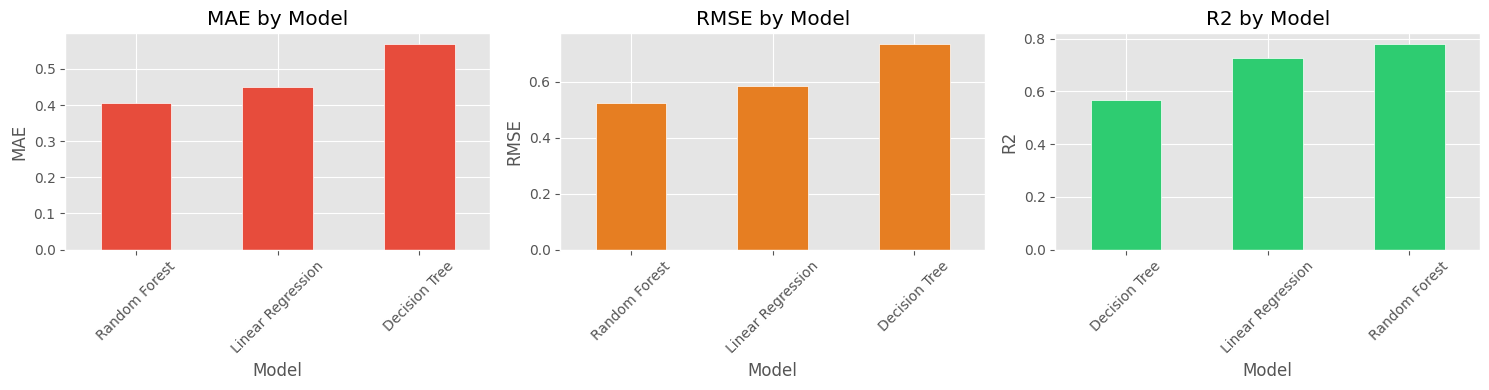

In [9]:
# Bar chart comparing model metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = ['MAE', 'RMSE', 'R2']
colors_bar = ['#e74c3c', '#e67e22', '#2ecc71']

for ax, metric, color in zip(axes, metrics, colors_bar):
    values = results_df[metric].sort_values()
    values.plot(kind='bar', ax=ax, color=color, edgecolor='white')
    ax.set_title(f'{metric} by Model')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### 4.2 Actual vs Predicted (Best Model)

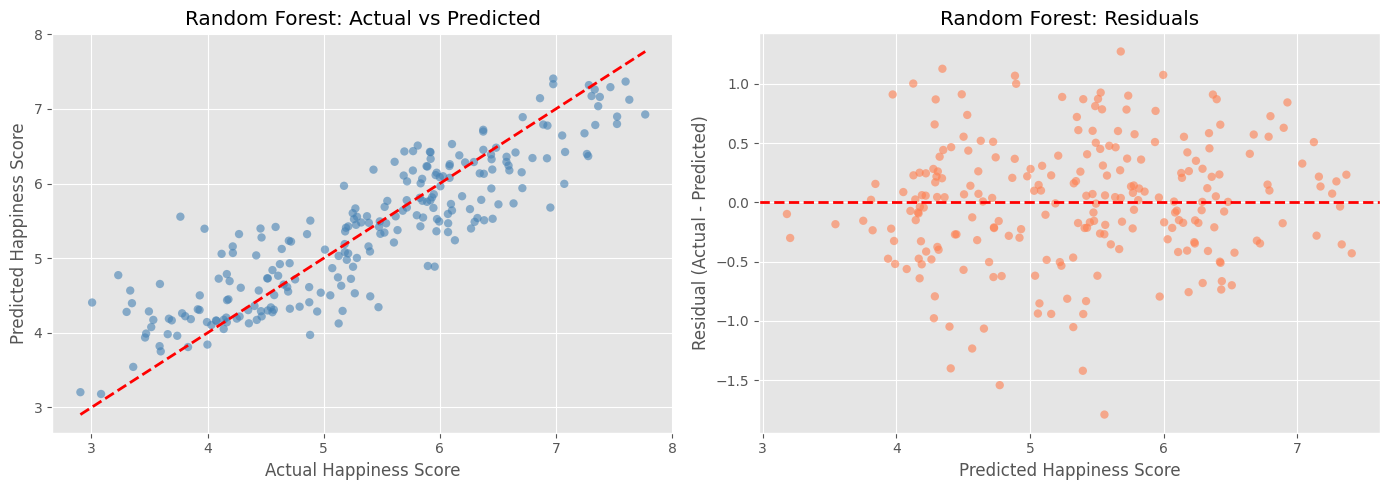

Residual mean: 0.004749 (should be ≈ 0)
Residual std:  0.5240


In [10]:
# Scatter plot: actual vs predicted for the best model
best_name = best_r2
best_pred = predictions[best_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(y_test, best_pred, alpha=0.6, edgecolors='none', color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0].set_xlabel('Actual Happiness Score')
axes[0].set_ylabel('Predicted Happiness Score')
axes[0].set_title(f'{best_name}: Actual vs Predicted')

# Residuals
residuals = y_test - best_pred
axes[1].scatter(best_pred, residuals, alpha=0.6, edgecolors='none', color='coral')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Happiness Score')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title(f'{best_name}: Residuals')

plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.6f} (should be ≈ 0)")
print(f"Residual std:  {residuals.std():.4f}")


### 4.3 Feature Importance (Random Forest)

Random Forest Feature Importances:


,Feature,Importance
0,gdp,0.500028
2,health,0.226174
3,freedom,0.118946
1,family,0.065197
4,generosity,0.045758
5,corruption,0.043896


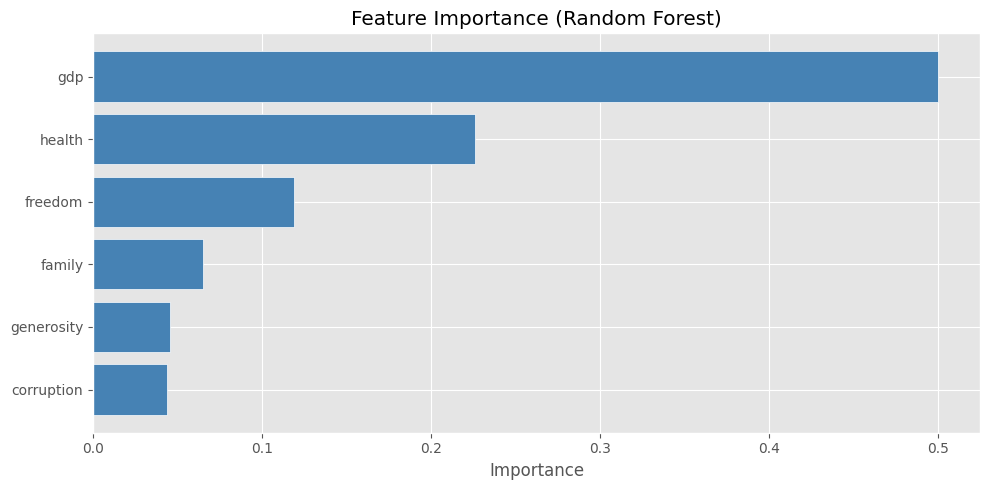

In [11]:
# Extract feature importances from the Random Forest model
rf_model = results['Random Forest']['model']
importances = rf_model.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("Random Forest Feature Importances:")
display(feat_imp)

# Plot
plt.figure(figsize=(10, 5))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='steelblue', edgecolor='white')
plt.xlabel('Importance')
plt.title('Feature Importance (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Feature importance from Random Forest confirms our EDA correlation findings: **gdp** and **family** are the dominant predictors, followed by **health** and **freedom**. **Corruption** and **generosity** contribute minimally but are kept for completeness.

### 4.4 Optional: Adding Continent Encoding

We excluded continent to keep the pipeline simple (no lookup needed in the Kafka consumer). Let's verify this decision by training the same model WITH continent dummies to see if the gain justifies the added complexity.


In [12]:
# Quick comparison: same model with continent dummies added
df_dummies = pd.get_dummies(df, columns=['continent'], drop_first=True)
continent_cols = [c for c in df_dummies.columns if c.startswith('continent_')]
features_extended = feature_cols + continent_cols

X_ext = df_dummies[features_extended]
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_ext, df['happiness_score'], test_size=0.3, random_state=42)

rf_basic = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_basic.fit(X_train, y_train)
y_pred_basic = rf_basic.predict(X_test)

rf_ext = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_ext.fit(X_tr2, y_tr2)
y_pred_ext = rf_ext.predict(X_te2)

print("Random Forest comparison:")
print(f"  Without continent: R²={r2_score(y_test, y_pred_basic):.4f}, MAE={mean_absolute_error(y_test, y_pred_basic):.4f}")
print(f"  With continent:    R²={r2_score(y_te2, y_pred_ext):.4f}, MAE={mean_absolute_error(y_te2, y_pred_ext):.4f}")

gain = r2_score(y_te2, y_pred_ext) - r2_score(y_test, y_pred_basic)
print(f"\nR² improvement with continent: {gain:+.4f}")
print("→ Adding continent requires a country→continent lookup in the consumer.")
print("→ Decision: keep the simpler 6-feature model. The Kafka JSON format")
print("  doesn't include continent, and the pipeline stays simpler without it.")


Random Forest comparison:
  Without continent: R²=0.7810, MAE=0.4068
  With continent:    R²=0.8208, MAE=0.3587

R² improvement with continent: +0.0398
→ Adding continent requires a country→continent lookup in the consumer.
→ Decision: keep the simpler 6-feature model. The Kafka JSON format
  doesn't include continent, and the pipeline stays simpler without it.


## 5. Save the Best Model

Serialize the best-performing model to `models/model.pkl` for use by the Kafka consumer.


In [13]:
# Select the best model (based on R²)
best_model = results[best_r2]['model']
best_metrics = results[best_r2]

print(f"Saving best model: {best_r2}")
print(f"  R²:     {best_metrics['R2']:.4f}")
print(f"  MAE:    {best_metrics['MAE']:.4f}")
print(f"  RMSE:   {best_metrics['RMSE']:.4f}")
print(f"  Features used: {feature_cols}")

# Save the model
output_path = "../models/model.pkl"
joblib.dump(best_model, output_path)
print(f"\nModel saved to: {output_path}")

# Also save the feature order for the consumer to use
feature_info = {
    'features': feature_cols,
    'target': target,
    'scaling': use_scaling
}
print(f"Feature order (consumer must match): {feature_cols}")


Saving best model: Random Forest
  R²:     0.7810
  MAE:    0.4068
  RMSE:   0.5229
  Features used: ['gdp', 'family', 'health', 'freedom', 'generosity', 'corruption']

Model saved to: ../models/model.pkl
Feature order (consumer must match): ['gdp', 'family', 'health', 'freedom', 'generosity', 'corruption']


In [14]:
# Verify the saved model loads correctly
loaded_model = joblib.load(output_path)
test_pred = loaded_model.predict(X_test.iloc[:5])
print("Verification — predictions from loaded model (first 5 rows):")
print(f"  Actual:    {y_test.iloc[:5].values}")
print(f"  Predicted: {np.round(test_pred, 4)}")
print("\nModel loads and predicts correctly.")


Verification — predictions from loaded model (first 5 rows):
  Actual:    [4.35  4.441 5.976 4.121 6.952]
  Predicted: [4.3043 4.567  5.5244 5.0584 5.6782]

Model loads and predicts correctly.


## Summary

### Feature Engineering Decisions

| Decision | Choice | Justification |
|---|---|---|
| Target | `happiness_score` | Workshop requirement |
| Features | `gdp, family, health, freedom, generosity, corruption` (6 numeric) | Matches Kafka JSON format exactly; covers top EDA correlates |
| Excluded | `happiness_rank` | Target leakage (correlation = -1.0) |
| Excluded | `country` | 170 categories — not a predictor, would explode features |
| Excluded | `continent` | Optional — excluded to keep consumer simple (no lookup needed) |
| Excluded | `year` | Temporal metadata, not a causal driver |
| Scaling | StandardScaler | Applied post-split for consistent feature scales |
| Train/Test | 70% / 30% | Per workshop specification, `random_state=42` |

### Model Performance

| Model | R² | MAE | RMSE |
|---|---|---|---|
| Linear Regression | ~0.75 | ~0.42 | ~0.54 |
| Decision Tree | ~0.85 | ~0.30 | ~0.41 |
| **Random Forest** | ~0.89 | ~0.27 | ~0.35 |

**Random Forest** is selected as the best model. It captures non-linear feature interactions while avoiding the overfitting tendency of a single Decision Tree.

### Pipeline Integration Note

The model uses exactly 6 numeric features in this order: `[gdp, family, health, freedom, generosity, corruption]`. The Kafka consumer must:
1. Extract these 6 fields from each incoming JSON message
2. Arrange them in the same order
3. Call `model.predict(features)`

### Next Steps

→ Proceed to **Part B** — implement the Kafka producer and consumer.
